<a href="https://colab.research.google.com/github/arojocz/machine-learning-Projects/blob/main/mti_pruebatecnica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Regresión logística (clasificación binaria)

# Por Luis Angel Rojo Chavez
## github: https://github.com/arojocz
## linkedin: https://www.linkedin.com/in/luis-angel-rojo-chavez/

## Dataset: breast cancer

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
try:
    import ucimlrepo
except ImportError:
    print("ucimlrepo not found. Installing...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "ucimlrepo"])
    import ucimlrepo

Como ejemplo se usará el dataset de breast cancer directo de uci, se usa la filosofia  tensorial con la ayuda de numpy sin usar otras bibliotecas como scikitlearn, de una entrada con m ejemplos (569) y n features (30 features).

Nota 1: no se hizo feature selection por facilidad además de reconocer que los expertos en medicina y cancer eligieron esas features.

Nota 2: la limpieza del dataset se omite porque se eligió un dataset limpio sin missing values o con datos categoricos que requirieran tecnicas como one hot encoding o más complejas.

Nota 3: solo tiene la clase como categorica a B (beningno) y M (maligno) mapeados a 0 y 1.

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_diagnostic = fetch_ucirepo(id=17)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_diagnostic.data.features
y = breast_cancer_wisconsin_diagnostic.data.targets

# Map 'M' to 1 and 'B' to 0 in the 'Diagnosis' column
y.loc[:, 'Diagnosis'] = y['Diagnosis'].map({'M': 1, 'B': 0})

# metadata
print(breast_cancer_wisconsin_diagnostic.metadata)

# variable information
print(breast_cancer_wisconsin_diagnostic.variables)


y = y.to_numpy().reshape(-1, 1)
y = y.astype(np.float64)
X = X.to_numpy().astype(np.float64)

count_zeros = (y == 0).sum()
count_ones = (y == 1).sum()

# IR
minority_class = count_zeros if count_zeros < count_ones else count_ones
majority_class = count_zeros if count_zeros > count_ones else count_ones
IR = majority_class / minority_class
print(f"Imbalance Ratio (IR): {IR:.2f}")

mu = np.mean(X, axis=0)
sigma = np.std(X, axis=0)

# normalize
X = (X - mu) / (sigma + 1e-8) #broadcasted operation and in case of div zero is 1e-8

print(X)

{'uci_id': 17, 'name': 'Breast Cancer Wisconsin (Diagnostic)', 'repository_url': 'https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic', 'data_url': 'https://archive.ics.uci.edu/static/public/17/data.csv', 'abstract': 'Diagnostic Wisconsin Breast Cancer Database.', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 569, 'num_features': 30, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['Diagnosis'], 'index_col': ['ID'], 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 1993, 'last_updated': 'Fri Nov 03 2023', 'dataset_doi': '10.24432/C5DW2B', 'creators': ['William Wolberg', 'Olvi Mangasarian', 'Nick Street', 'W. Street'], 'intro_paper': {'ID': 230, 'type': 'NATIVE', 'title': 'Nuclear feature extraction for breast tumor diagnosis', 'authors': 'W. Street, W. Wolberg, O. Mangasarian', 'venue': 'Electronic imaging', 'year': 1993, 'journal': None, 'DOI': '1

Se realizar un split de 70% para entrenamiento y 30% para prueba. Se trata de hacer un mezclado pseudoaleatorio.

In [ ]:
m = X.shape[0]
idx = np.arange(m)
np.random.seed(27)
np.random.shuffle(idx)

cut = int(0.7 * m)

# Separate using idx shuffled
train_idx, test_idx = idx[:cut], idx[cut:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

Train: 398 | Test: 171


In [ ]:
def sigmoid(s):
  return 1 / (1 + np.exp(-s))

In [ ]:
m = np.shape(X_train)[0] # extract number of examples from the tensor-like X vector
n = np.shape(X_train)[1] # extract dimension features from the tensor-like X vector
m_test = np.shape(X_test)[0]
print(f'the shape of X in training is {m} examples and {n} features')

the shape of X in training is 398 examples and 30 features


In [ ]:
def initial_parameters(n):
  #  are features number in Dataset
  w = np.random.randn(n,1) * 0.01 # restriction of small w for vanishing gradient
  b = 0
  return w,b


In [ ]:
w, b = initial_parameters(n)
print("w = ", w, f"b = {b}", sep="\n")
print(w.shape)

w = 
[[ 0.01020946]
 [ 0.00322727]
 [ 0.01919937]
 [-0.00899592]
 [ 0.00013533]
 [-0.0051134 ]
 [ 0.00522139]
 [ 0.00902506]
 [ 0.00204784]
 [-0.01592317]
 [ 0.0152332 ]
 [-0.01607623]
 [ 0.00712047]
 [ 0.00109317]
 [-0.00222839]
 [ 0.00679638]
 [ 0.00079045]
 [-0.00082335]
 [ 0.00852563]
 [-0.00717308]
 [ 0.01092577]
 [ 0.00477209]
 [-0.00917982]
 [ 0.00199926]
 [-0.01773056]
 [-0.01448399]
 [-0.00959855]
 [-0.0194281 ]
 [ 0.00017908]
 [ 0.02771386]]
b = 0
(30, 1)


In [ ]:
def forward_pass(X,w, b):
  s = np.dot(X, w) + b # in tensor form and for not transposing X, dot product of Xw is ok
  y_hat = sigmoid(s).reshape(-1,1) #for not having a shape (m,)
  return y_hat


In [ ]:
y_hat_train = forward_pass(X_train,w,b)
print(y_hat_train.shape, y_train.shape)

(398, 1) (398, 1)


In [ ]:
def loss(y, y_hat, m):
  l = (-1 / m) * np.sum(y * np.log(y_hat + 1e-15) + (1 - y) * np.log(1 - y_hat + 1e-15))
  # + 1e-15 is for not encountering zero division in log function
  return l


In [ ]:
l = loss(y_train, y_hat_train, m)
print(l)

0.696356496033676


In [ ]:
def backward_propagation(X,y,y_hat,m):
  ds = y_hat - y
  dw = (1 / m) * np.dot(X.T, ds) # shape ->(features, 1)
  db = (1 / m) * np.sum(ds) # as update in bias is a scalar, then normalizing 1/m is necessary
  return dw, db


In [ ]:
dw, db = backward_propagation(X_train,y_train,y_hat_train,m)
print(db)

0.14075501804493593


In [ ]:
def train(X, y,m,X_test, y_test, m_test, epochs, alpha = 0.001):
  w, b = initial_parameters(n)
  loss_history = []
  val_loss_history = []

  for i in range(epochs):
    y_hat = forward_pass(X, w, b)
    l = loss(y, y_hat, m)

    #validation just for analyze overfitting

    y_hat_test = forward_pass(X_test, w, b)
    l_test = loss(y_test, y_hat_test, m_test)

    loss_history.append(l)
    val_loss_history.append(l_test)

    dw, db = backward_propagation(X, y, y_hat, m)

    w = w - alpha * dw
    b = b - alpha * db

    if i % 100 == 0:
      print(f"Epoch {i:4d} | Cost train: {l:.4f} | Cost Val {l_test:4f}")

  return w, b, loss_history, val_loss_history

In [ ]:
w, b, loss_history, val_history = train(X_train,y_train,m,X_test, y_test, m_test, epochs = 20000, alpha = 0.01)

Epoch    0 | Cost train: 0.7021 | Cost Val 0.702745
Epoch  100 | Cost train: 0.2557 | Cost Val 0.231280
Epoch  200 | Cost train: 0.1883 | Cost Val 0.174342
Epoch  300 | Cost train: 0.1575 | Cost Val 0.150885
Epoch  400 | Cost train: 0.1391 | Cost Val 0.137820
Epoch  500 | Cost train: 0.1267 | Cost Val 0.129409
Epoch  600 | Cost train: 0.1177 | Cost Val 0.123505
Epoch  700 | Cost train: 0.1107 | Cost Val 0.119112
Epoch  800 | Cost train: 0.1051 | Cost Val 0.115705
Epoch  900 | Cost train: 0.1006 | Cost Val 0.112979
Epoch 1000 | Cost train: 0.0967 | Cost Val 0.110743
Epoch 1100 | Cost train: 0.0934 | Cost Val 0.108873
Epoch 1200 | Cost train: 0.0905 | Cost Val 0.107284
Epoch 1300 | Cost train: 0.0880 | Cost Val 0.105915
Epoch 1400 | Cost train: 0.0858 | Cost Val 0.104723
Epoch 1500 | Cost train: 0.0838 | Cost Val 0.103675
Epoch 1600 | Cost train: 0.0820 | Cost Val 0.102746
Epoch 1700 | Cost train: 0.0804 | Cost Val 0.101916
Epoch 1800 | Cost train: 0.0789 | Cost Val 0.101170
Epoch 1900 |

In [ ]:
y_hat_test = forward_pass(X_test, w, b)
y_pred = (y_hat_test >= 0.5).astype(int)

In [ ]:
print(w, f'b = {b}', sep='\n')

[[ 0.69944187]
 [ 0.86805092]
 [ 0.6470138 ]
 [ 0.68537412]
 [ 0.27471761]
 [-0.13994185]
 [ 0.70778831]
 [ 0.90195418]
 [ 0.21885559]
 [-0.65246585]
 [ 1.13570498]
 [-0.45557114]
 [ 0.66407197]
 [ 0.91286932]
 [ 0.31038272]
 [-0.80694503]
 [-0.08972243]
 [ 0.30823661]
 [-0.31247619]
 [-0.7855209 ]
 [ 1.10961069]
 [ 1.18366023]
 [ 0.95225583]
 [ 1.01503233]
 [ 0.83996001]
 [ 0.24546344]
 [ 0.70278716]
 [ 1.16953425]
 [ 0.96190142]
 [ 0.15367861]]
b = -0.5039306698063746


In [ ]:
tp = np.sum((y_test == 1) & (y_pred == 1))
tn = np.sum((y_test == 0) & (y_pred == 0))
fp = np.sum((y_test == 0) & (y_pred == 1))
fn = np.sum((y_test == 1) & (y_pred == 0))

In [ ]:
accuracy = (tp + tn) / len(y_test)
precision = tp / (tp + fp) if (tp + fp) > 0 else 0
recall = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

### Nota importante
En datasets con IR > 1.5 (imbalance ratio mayor a 1.5) significa datasets desbalanceados, en este ejemplo se alcanza 1.68, por lo que ya se condidera desbalanceado, algunos autores ven incorrecto mostrar accuracy en estas situaciones, como medida de desempeño engañosa y poco informativa, este no es un caso extremo de desbalance pero será mejor fijarse en el F1-score.

In [ ]:
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")
print("\n--- Matriz de Confusión ---")
print(f"True positive (M classified and M in reality):  {tp}")
print(f"True negative (B clasified and B in reality):   {tn}")
print(f"False positives:                                {fp}")
print(f"False negatives:                                {fn}")

Accuracy:  0.9825
Precision: 0.9853
Recall:    0.9710
F1-Score:  0.9781

--- Matriz de Confusión ---
True positive (M classified and M in reality):  67
True negative (B clasified and B in reality):   101
False positives:                                1
False negatives:                                2


No se aplican técnicas de validación reales, como early stopping o demás, sólo se estima c´ómo el modelo puede generalizar a lo largo del entrenamiento probando en los datos de test directamente.

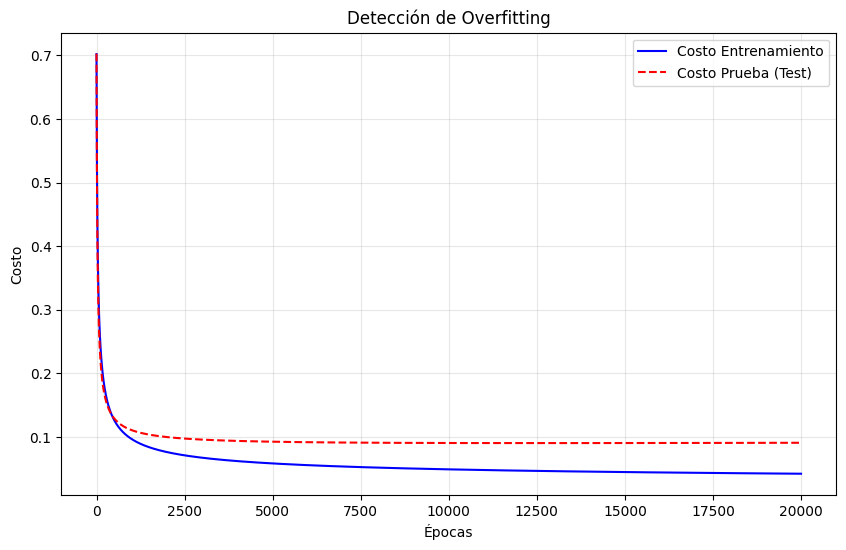

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(loss_history, label='Costo Entrenamiento', color='blue')
plt.plot(val_history, label='Costo Prueba (Test)', color='red', linestyle='--')

plt.title('Detección de Overfitting')
plt.xlabel('Épocas')
plt.ylabel('Costo')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Conclusiones

El costo final es bajo (cercano a 0.05 - 0.1), lo que significa que el modelo entendió bien el problema.

La brecha entre las curvas es mínima, lo que garantiza que el modelo funcionará con pacientes nuevos con la misma precisión que muestra en el entrenamiento, si hubiera overfitting la generalización del modelo a lo largo del entrenamiento podría ir empeorando mucho, cosa que no pasa.

El entrenamiento se nota que desde aproximadamente la epoch 10000 ya no es necesario seguir.

Es un dataset muy sencillo, para grandes cantidades de datos hay que probar todo tipo de técnicas para mejorar la generalización lo más posible.